# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Calabozo, Nicolas Daniel
- Alumno 2 : Lapolla, Martín Facundo

## Librerías

In [10]:
import os
import numpy as np
import cv2
import ssl
import time
import uuid
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from facenet_pytorch import MTCNN, InceptionResnetV1
from tqdm import tqdm
from dotenv import load_dotenv
from typing import Any, Literal, Optional
from pydantic import BaseModel, ConfigDict, Field
import copy

from sklearn.metrics import pairwise_distances
import psycopg
from pgvector.psycopg import register_vector 


ssl._create_default_https_context = ssl._create_unverified_context

import sys
sys.path.append(os.path.abspath('./src'))
from lib.storage.pgvector_store import PgVectorEmbeddingStore
from lib.schemas import EmbeddingRecord

load_dotenv(dotenv_path="./src/.env")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [11]:
#Setup de BBDD vectorial 
store = PgVectorEmbeddingStore(
    dbname=os.getenv("POSTGRES_DB","faces"),
    user=os.getenv("POSTGRES_USER", "faces_user"),
    password=os.getenv("POSTGRES_PASSWORD", "faces_pass"),
    host=os.getenv("POSTGRES_HOST", "localhost"),
    port=int(os.getenv("POSTGRES_PORT", "5432")),
    embedding_dim=int(os.getenv("EMBEDDING_DIM", 512))
)

In [12]:
#Setup de MTCNN IMG(160x160px)
mtcnn = MTCNN(image_size=160, margin=20, device=device, post_process=True)

### EDA

In [13]:
lfw_data = fetch_lfw_people(
    min_faces_per_person=20,
    color=True,
    resize=1.0,
    slice_=None, #type: ignore
    download_if_missing=True)
print("Descarga completa - Imágenes sin recortar, a color, tamaño 250x250")

X = lfw_data.images #type: ignore
y = lfw_data.target #type: ignore
num_classes = len(lfw_data.target_names) #type: ignore

# Dividimos en Train y Validation (80% / 20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

class SklearnLFWDataset(Dataset):
    def __init__(self, images, labels, mtcnn):
        self.images = images
        self.labels = labels
        self.mtcnn = mtcnn

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_np = (self.images[idx] * 255).astype(np.uint8)
        face = self.mtcnn(img_np)
        if face is None:
            face = torch.zeros(3, 160, 160)
            
        return face, self.labels[idx]

#Dataset de Train
train_loader = DataLoader(SklearnLFWDataset(X_train, y_train, mtcnn), batch_size=32, shuffle=True)
print("Loader de Train instanciado")
#Dataset de Validación
val_loader = DataLoader(SklearnLFWDataset(X_val, y_val, mtcnn), batch_size=32, shuffle=False)
print("Loader de Validación instanciado")

Descarga completa - Imágenes sin recortar, a color, tamaño 250x250
Loader de Train instanciado
Loader de Validación instanciado


### Entrenamiento

#### Clases

In [14]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

#### Funciones

In [15]:
#Función para obtener el modelo preparado para finetuning
def get_model(num_classes):
    model = InceptionResnetV1(pretrained='vggface2', classify=True).to(device)
    #Congelamos el backbone
    for param in model.parameters():
        param.requires_grad = False
    #Descongelamos capas previas a la clasificación final
    for param in model.last_linear.parameters():
        param.requires_grad = True
    for param in model.last_bn.parameters():
        param.requires_grad = True
    #Generamos el nuevo head con el número de clases de LFW
    model.logits = nn.Linear(512, num_classes).to(device)    
    return model

In [16]:
def train_con_early_stopping(model, train_loader, val_loader, max_epochs=20, device='cuda'):
    criterion = nn.CrossEntropyLoss() 
    parametros_a_entrenar = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.Adam(parametros_a_entrenar, lr=0.001)
    
    early_stopping = EarlyStopping(patience=3, min_delta=0.01)
    
    train_losses = []
    val_losses = []
    
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs} [Train]"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch [{epoch+1}/{max_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
        
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print("Early stopping disparado. Deteniendo entrenamiento.")
            break
            
    model.load_state_dict(best_model_wts)
    return model, train_losses, val_losses

In [22]:
model_dir = os.getenv("MODEL_PATH", "models")
model_name = os.getenv("MODEL_NAME", "inception_resnet_lfw_finetuned.pth")
save_path = os.path.join(model_dir, model_name)
model = get_model(len(lfw_data.target_names)) #type: ignore
if os.path.exists(save_path):
    print(f"El modelo ya existe en {save_path}. Cargando pesos guardados.")
    model.load_state_dict(torch.load(save_path, map_location=device))
    train_losses, val_losses = [], []  # No tenemos las pérdidas de entrenamiento anteriores, solo cargamos el modelo
else:
    print("Iniciando el entrenamiento del modelo")
    model, train_losses, val_losses = train_con_early_stopping(model, train_loader, val_loader, max_epochs=20, device=device)
    os.makedirs(model_dir, exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print(f"Modelo guardado exitosamente en: {save_path}")

El modelo ya existe en models\face_detection.pth. Cargando pesos guardados.


In [23]:
# Graficar curvas de pérdida
if(train_losses and val_losses):
    plt.figure(figsize=(10,5))
    plt.title("Modelo InceptionResnetV1 Fine-Tuned")
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Curvas de Aprendizaje')
    plt.xlabel('Época')
    plt.ylabel('Pérdida (Cross Entropy)')
    plt.legend()
    plt.show()

In [ ]:
def extract_and_store_embeddings(modelo, loader, store=None, target_names=None, device='cuda', guardar_en_bd=True):
    """
    Función para la extracción de embeddings en lotes (batches).
    Si guardar_en_bd=True, también los almacena en PGVector.
    """
    modelo.eval()
    estado_original_classify = getattr(modelo, 'classify', False)
    modelo.classify = False

    embeddings_list = []
    etiquetas_list = []
    
    global_idx = 0 

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Extrayendo embeddings"):
            inputs = inputs.to(device)
            
            batch_embeddings = modelo(inputs) 
            batch_emb_np = batch_embeddings.cpu().numpy()
            labels_np = labels.cpu().numpy()
            
            embeddings_list.append(batch_emb_np)
            etiquetas_list.append(labels_np)
            
            if guardar_en_bd:
                # Validamos que exista el store y los nombres
                if store is None or target_names is None:
                    raise ValueError("Para guardar en BD necesitas pasar 'store' y 'target_names'.")
                    
                for i in range(len(batch_emb_np)):
                    emb = batch_emb_np[i]
                    label_id = labels_np[i]
                    person_name = target_names[label_id] 
                    
                    record = EmbeddingRecord(
                        id_imagen=str(uuid.uuid4()),
                        embedding=emb.flatten().tolist(), 
                        path=f"{person_name}_loader_{global_idx}.jpg", 
                        etiqueta=person_name,
                        metadata={"source": "LFW Fast DataLoader"}
                    )
                    store.append(record)
                    global_idx += 1
                
    modelo.classify = estado_original_classify
        
    return np.vstack(embeddings_list), np.concatenate(etiquetas_list)

In [ ]:
#Extraemos embeddings del modelo sin entrenar
modelo_base = InceptionResnetV1(pretrained='vggface2', classify=False).to(device)
print("Evaluando Modelo Base")
#No guardamos los embeddings del modelo base en la BD, solo los extraemos para evaluación inmediata.
#Nos sirven para una comparación directa con el modelo fine-tuned sin popular la base con datos
#con embeddings de un modelo no entrenado
emb_train_base, y_train_base = extract_and_store_embeddings(modelo_base, train_loader, store, lfw_data.target_names, guardar_en_bd=False) #type: ignore
emb_val_base, y_val_base = extract_and_store_embeddings(modelo_base, val_loader, store, lfw_data.target_names, guardar_en_bd=False) #type: ignore

# Evaluamos con KNN usando distancia coseno
knn_base = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn_base.fit(emb_train_base, y_train_base)
acc_base = accuracy_score(y_val_base, knn_base.predict(emb_val_base))
print(f"Accuracy Modelo BASE: {acc_base*100:.2f}%")

try:
    # Evaluamos el modelo fine-tuned
    print("\nEvaluando Modelo Fine-Tuned")
    #Además de extraer los embeddings, los guardamos en la base de datos para futuras consultas
    emb_train_ft, y_train_ft = extract_and_store_embeddings(model, train_loader, store, lfw_data.target_names, guardar_en_bd=True) #type: ignore
    emb_val_ft, y_val_ft = extract_and_store_embeddings(model, val_loader, store, lfw_data.target_names, guardar_en_bd=False) #type: ignore
    # Evaluamos con KNN
    knn_ft = KNeighborsClassifier(n_neighbors=3, metric='cosine')
    knn_ft.fit(emb_train_ft, y_train_ft)
    acc_ft = accuracy_score(y_val_ft, knn_ft.predict(emb_val_ft))
    print(f"🏆 Accuracy Modelo FINE-TUNED: {acc_ft*100:.2f}%")
except Exception as e:
    print(f"No se pudo cargar el modelo fine-tuned: {e}")

Evaluando modelo base


Extrayendo embeddings: 100%|██████████| 19/19 [00:28<00:00,  1.48s/it]


🏆 Accuracy Modelo BASE: 97.19%

Evaluando modelo FINE-TUNED...


Extrayendo embeddings: 100%|██████████| 19/19 [00:27<00:00,  1.44s/it]

🏆 Accuracy Modelo FINE-TUNED: 97.19%


Calculando Curva ROC para el modelo BASE...


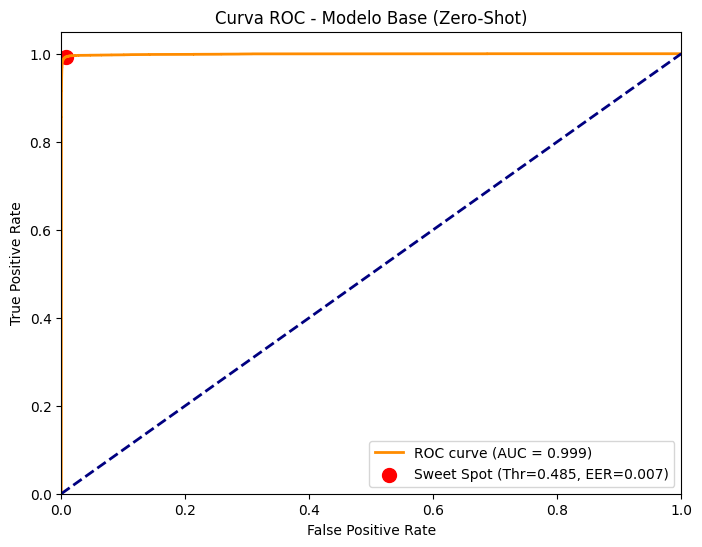

In [ ]:
def plot_roc_curve(embeddings, labels, title="Curva ROC"):
    # Calculamos la matriz de similitud coseno completa
    dist_matrix = pairwise_distances(embeddings, metric='cosine')
    sim_matrix = 1 - dist_matrix # Similitud coseno (1 a -1)
    
    y_true = []
    y_scores = []
    
    n = len(labels)
    # Extraemos pares (solo la mitad superior de la matriz para no duplicar)
    for i in range(n):
        for j in range(i+1, n):
            is_same = int(labels[i] == labels[j])
            y_true.append(is_same)
            y_scores.append(sim_matrix[i, j])
            
    # Calculamos FPR, TPR y AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Encontrar el Sweet Spot (Umbral óptimo, EER - Equal Error Rate)
    # Buscamos el punto donde False Positive Rate y False Negative Rate (1-TPR) se cruzan
    fnr = 1 - tpr
    eer_threshold_idx = np.nanargmin(np.absolute((fnr - fpr)))
    opt_threshold = thresholds[eer_threshold_idx]
    eer = fpr[eer_threshold_idx]
    
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.scatter(fpr[eer_threshold_idx], tpr[eer_threshold_idx], color='red', s=100, label=f'Sweet Spot (Thr={opt_threshold:.3f}, EER={eer:.3f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

# Graficar para el modelo Base
print("Calculando Curva ROC para el modelo BASE...")
plot_roc_curve(emb_val_base, y_val_base, title="Curva ROC - Modelo Base (Zero-Shot)")

# Graficar para el modelo Fine-Tuned
if 'emb_val_ft' in locals():
    print("Calculando Curva ROC para el modelo FINE-TUNED...")
    plot_roc_curve(emb_val_ft, y_val_ft, title="Curva ROC - Modelo Fine-Tuned")
